In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.animation as animation 

from sklearn.cluster import KMeans 

from sklearn.datasets import make_blobs 

In [5]:
X, y_true = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=1.0,
    random_state=42
)

df = pd.DataFrame(X, columns=["Feature 1", "Feature 2"])
df.head()

,Feature 1,Feature 2
0,-7.689054,6.620346
1,-9.576514,-6.934404
2,6.829682,1.164871
3,-2.901306,7.550771
4,-5.678413,-7.288185


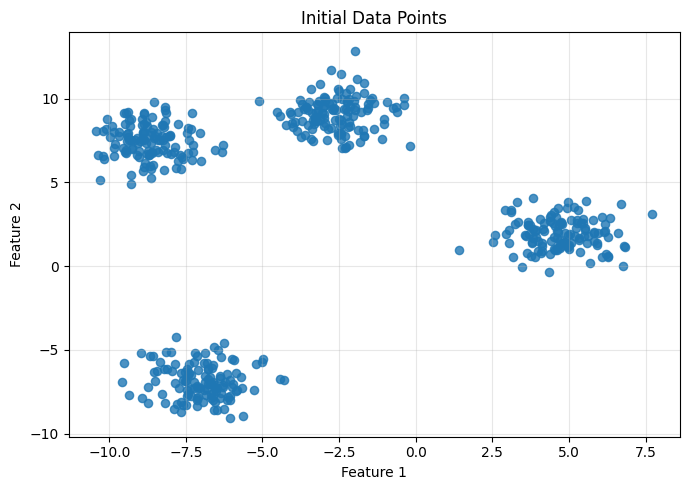

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(df["Feature 1"], df["Feature 2"], s=35, 
    alpha=0.8)

plt.title("Initial Data Points")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
kmeans = KMeans(n_clusters=4, random_state=42)

In [8]:
kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 2)","[

In [9]:
df["cluster_kmeans"] = kmeans.labels_

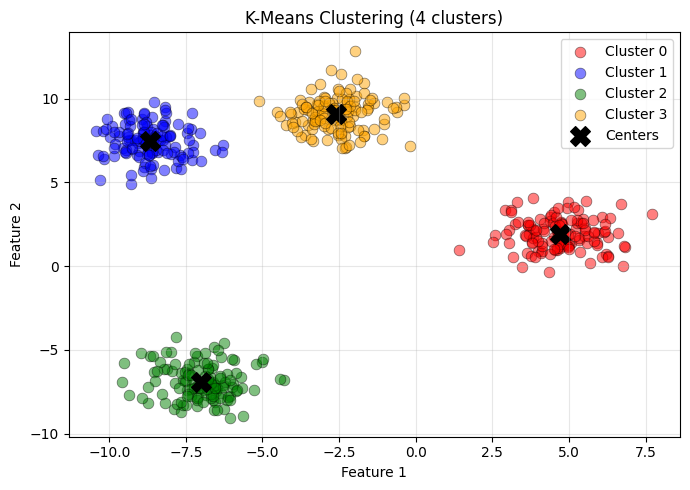

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))


colors = ["red", "blue", "green", "orange"]

for cluster in range(4):
    subset = df[df["cluster_kmeans"] == cluster]
    ax.scatter(
        subset["Feature 1"],
        subset["Feature 2"],
        color=colors[cluster],
        label=f"Cluster {cluster}",
        s=60,
        alpha=0.5,
        edgecolors="black",   
        linewidth=0.5    
    )

centers = kmeans.cluster_centers_
ax.scatter(
    centers[:, 0],
    centers[:, 1],
    c="black",
    marker="X",
    s=200,
    label="Centers"

)

ax.set_title("K-Means Clustering (4 clusters)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
from sklearn.cluster import DBSCAN

In [16]:
dbscan = DBSCAN(eps=0.8, min_samples=5)

In [17]:
dbscan.fit(X) 

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.8
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
"components_ components_: ndarray of shape (n_core_samples, n_features)Copy of each core sample found by training.","ndarray[float64](466, 2)","[[-7.69, 6.62], [-2.9 , 7.55], [-5.68,-7.29], ..., [-7.22,-5.21], [-7.4 ,-5.83], [ 5.16, 3.51]]"
"core_sample_indices_ core_sample_indices_: ndarray of shape (n_core_samples,)Indices of core samples.","ndarray[int64](466,)","[ 0, 3, 4,...,497,498,499]"


In [18]:
df["cluster_dbscan"] = dbscan.labels_

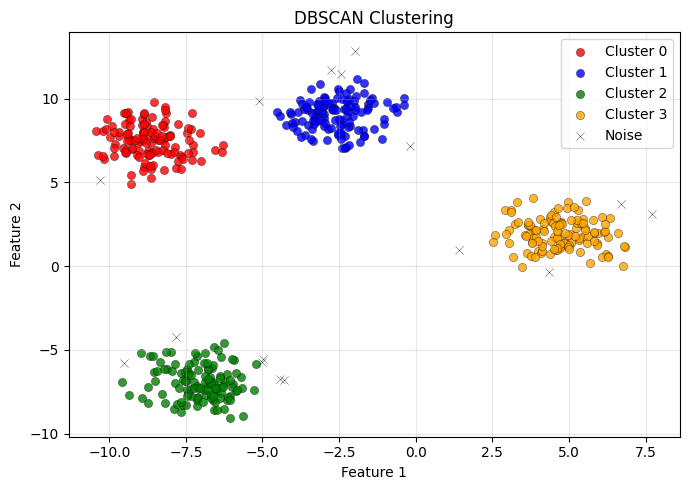

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))

unique_labels = set(dbscan.labels_)
colors = ["red", "blue", "green", "orange", "purple", "brown", "pink", "gray"]

for i, label in enumerate(unique_labels):
    if label == -1:
        color = "black"
        marker = "x"
        label_name = "Noise"
    else:
        color = colors[i % len(colors)]
        marker = "o"
        label_name = f"Cluster {label}"
    
    subset = df[df["cluster_dbscan"] == label]
    ax.scatter(
        subset["Feature 1"],
        subset["Feature 2"],
        color=color,
        marker=marker,
        label=label_name,
        s=35,
        alpha=0.8,
        edgecolors="black" if label != -1 else None,
        linewidth=0.3
    )

ax.set_title("DBSCAN Clustering")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [23]:
noise_count = (df["cluster_dbscan"] == -1).sum()
print(f"мітка -1: {noise_count}")
print(f"Кількість кластерів: {len(set(dbscan.labels_)) - (1 if -1 in set(dbscan.labels_) else 0)}")
print(f"Розподіл по кластерах:\n{df['cluster_dbscan'].value_counts().sort_index()}")

мітка -1: 16
Кількість кластерів: 4
Розподіл по кластерах:
cluster_dbscan
-1     16
 0    124
 1    120
 2    119
 3    121
Name: count, dtype: int64
